# P5 - Modelo final - Predicciones
## Autor: Yasin Hanin Boukaddidi

In [2]:
import pandas as pd

df1 = pd.read_csv("tcga_simple_train.csv")

df1.head()

,patient_id,text,t
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3


In [3]:
df2 = pd.read_csv("tcga_simple_dev.csv")

df = pd.concat([df1, df2], ignore_index=True)

print(f"Total de filas combinadas: {len(df)}")
display(df.head())

Total de filas combinadas: 5846


,patient_id,text,t
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3


In [4]:
labels = list(sorted(set(df['t'].to_list())))
labels

['T1', 'T2', 'T3', 'T4']

In [5]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)

dataset = dataset.rename_column("t", "label")

label2id = {label: i for i, label in enumerate(labels)}
dataset = dataset.map(lambda x: {"label": label2id[x["label"]]})

print("Dataset preparado a partir del DataFrame:")
print(dataset)

Map:   0%|          | 0/5846 [00:00<?, ? examples/s]

Dataset preparado a partir del DataFrame:
Dataset({
    features: ['patient_id', 'text', 'label'],
    num_rows: 5846
})


In [6]:
NUM_LABELS = len(labels)

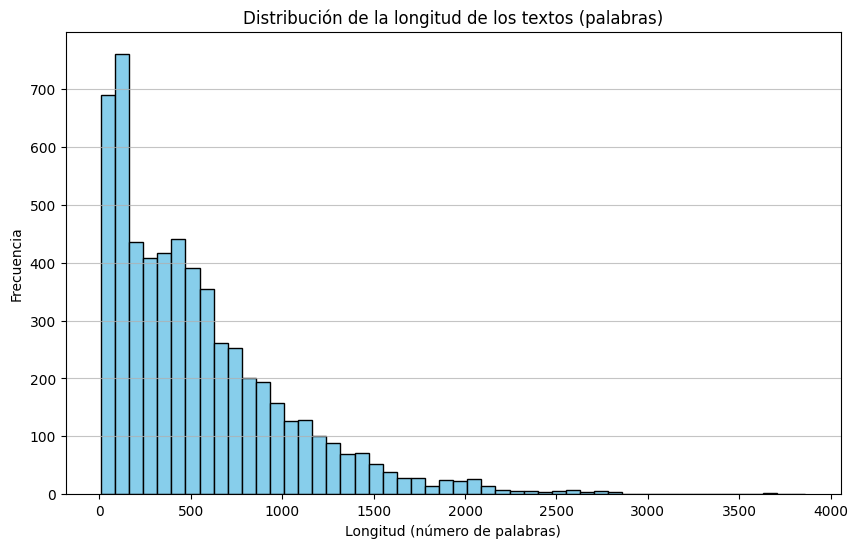

Longitud mínima: 8
Longitud media: 547.89
Longitud máxima: 3862
Percentil 90: 1198.5 (El 90% de los textos tienen esta longitud o menos)
Percentil 95: 1479.0 (El 95% de los textos tienen esta longitud o menos)


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos la longitud de los textos (por número de palabras)
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

# Visualización de la distribución
plt.figure(figsize=(10, 6))
plt.hist(df['text_len'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la longitud de los textos (palabras)')
plt.xlabel('Longitud (número de palabras)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Cálculo de percentiles para sugerir max_len
p90 = np.percentile(df['text_len'], 90)
p95 = np.percentile(df['text_len'], 95)
max_val = df['text_len'].max()

print(f"Longitud mínima: {df['text_len'].min()}")
print(f"Longitud media: {df['text_len'].mean():.2f}")
print(f"Longitud máxima: {max_val}")
print(f"Percentil 90: {p90} (El 90% de los textos tienen esta longitud o menos)")
print(f"Percentil 95: {p95} (El 95% de los textos tienen esta longitud o menos)")

In [8]:
from transformers import AutoTokenizer

model_id = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [9]:
# El modelo BERT tiene un límite estricto de 512 tokens.
# Aunque el dataset tenga textos más largos, debemos truncarlos.
MAX_LENGTH = 512
print(f"Tamaño máximo ajustado al límite de BERT: {MAX_LENGTH}")

Tamaño máximo ajustado al límite de BERT: 512


In [10]:
# Activamos 'truncation=True' para que los textos de más de 512 tokens se recorten automáticamente.
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

In [11]:
# se tokeniza todo el dataset por lotes
# sobre el diccionario con los tres split se llama a map para que aplique la función tokenize a cada split y al hacer batched a True se le está diciendo
# que lo haga por lotes
encoded_data = dataset.map(tokenize, batched=True)
encoded_data

Map:   0%|          | 0/5846 [00:00<?, ? examples/s]

Dataset({
    features: ['patient_id', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5846
})

In [12]:
# Primero, dividimos el dataset único en entrenamiento y una parte temporal (test + val)
train_test_split = encoded_data.train_test_split(test_size=0.2, seed=42)
# Luego dividimos esa parte temporal a la mitad para obtener validación y test
test_val_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = train_test_split['train']
validation_dataset = test_val_split['train']
test_dataset = test_val_split['test']

In [13]:
# se puede comprobar que todos los textos tienen el mismo tamaño
import random
for i in range(10):
    index = random.randint(0, train_dataset.num_rows)
    print('text:', index, ' len:', len(train_dataset[index]['input_ids']))


text: 385  len: 512
text: 2727  len: 512
text: 2576  len: 512
text: 3560  len: 512
text: 1623  len: 512
text: 3249  len: 512
text: 1864  len: 512
text: 2984  len: 512
text: 4140  len: 512
text: 4666  len: 512


In [14]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained("emilyalsentzer/Bio_ClinicalBERT", num_labels=NUM_LABELS)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [15]:
from transformers import TrainingArguments
args = TrainingArguments(output_dir="./outputs")
args.eval_strategy = "epoch"
args.logging_strategy = "epoch"
args.per_device_train_batch_size = 32
args.per_device_eval_batch_size = 32
args.num_train_epochs=5
display(args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=epoch,
eval_use_gather_object=False,
fp16=False,
f

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    y_true = pred.label_ids # labels reales
    y_pred = pred.predictions.argmax(-1) # predicciones

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true,y_pred, average='macro')

    return {
        'accuracy: ': accuracy,
        'f1: ': f1,
        'precision: ': precision,
        'recall: ': recall
    }

In [17]:
# Para crear un objeto de tipo Trainer hay que pasar el modelo, los conjuntos de entrenamiento y validación, los argumentos y la función para calcular
# las métricas.

from transformers import Trainer

trainer = Trainer(
    model = model,            # modelo que será ajustado
    train_dataset = train_dataset,
    eval_dataset = train_dataset,

    args = args,     # hiperparámetros
    compute_metrics=compute_metrics,    # función para computar las métricas
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [18]:
# Se lanza el entrenamiento. Esto puede tardar unos minutos.
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy:,F1:,Precision:,Recall:
1,1.257409,1.093158,0.534003,0.449315,0.610354,0.451145
2,0.945390,0.631718,0.752566,0.733252,0.740744,0.732528
3,0.624893,0.466421,0.833191,0.817016,0.839699,0.804080
4,0.466531,0.368657,0.870830,0.862272,0.864081,0.863727
5,0.356284,0.283653,0.909110,0.898564,0.894698,0.904411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=735, training_loss=0.7301015114297672, metrics={'train_runtime': 2909.5452, 'train_samples_per_second': 8.036, 'train_steps_per_second': 0.253, 'total_flos': 6151646938644480.0, 'train_loss': 0.7301015114297672, 'epoch': 5.0})

In [19]:
# Una vez finalizado el entrenamiento, es posible evaluar el modelo final sobre el conjunto de datos de validación.
trainer.evaluate()

{'eval_loss': 0.28365257382392883,
 'eval_accuracy: ': 0.9091103507271172,
 'eval_f1: ': 0.8985644281010551,
 'eval_precision: ': 0.8946976670148794,
 'eval_recall: ': 0.904410899576632,
 'eval_runtime': 133.7293,
 'eval_samples_per_second': 34.966,
 'eval_steps_per_second': 1.099,
 'epoch': 5.0}

In [20]:
# Evaluamos el modelo sobre el conjunto de test
test_results = trainer.predict(test_dataset)

print("Resultados en el conjunto de TEST:")
print(test_results.metrics)

Resultados en el conjunto de TEST:
{'test_loss': 0.8649892210960388, 'test_accuracy: ': 0.6991452991452991, 'test_f1: ': 0.6738120195667365, 'test_precision: ': 0.6712605996199178, 'test_recall: ': 0.6866596573186659, 'test_runtime': 16.7417, 'test_samples_per_second': 34.943, 'test_steps_per_second': 1.135}


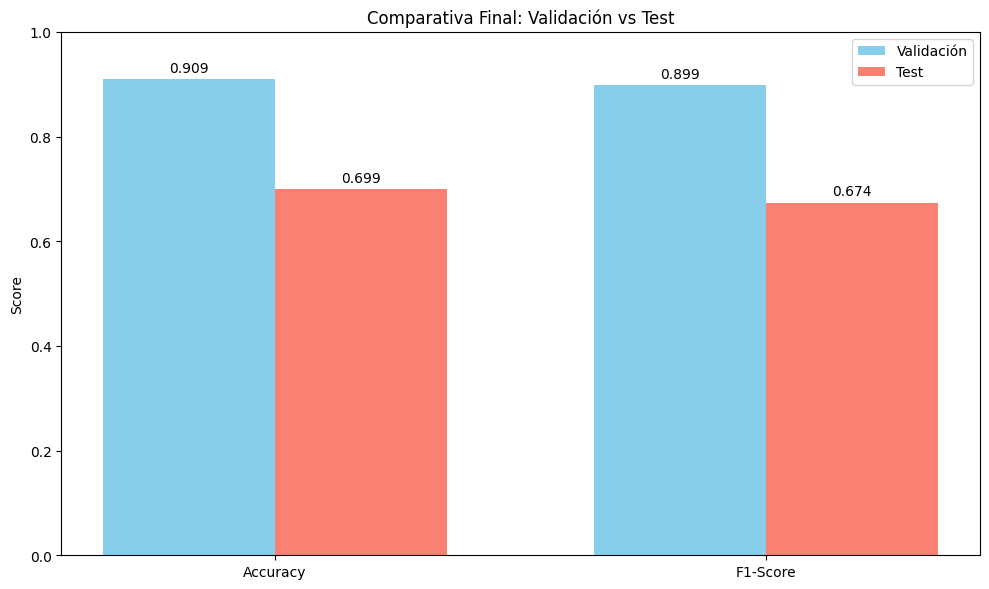

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Intentamos extraer métricas de validación del historial o del último estado
eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]

if not eval_logs:
    print("No se encontraron métricas de validación en el historial. Por favor, asegúrate de haber ejecutado trainer.train() o trainer.evaluate() primero.")
else:
    final_val_metrics = eval_logs[-1]
    test_metrics = test_results.metrics

    # Preparamos los datos para comparar Accuracy y F1
    # Nota: usamos los nombres exactos definidos en tu función compute_metrics
    labels_metrics = ['Accuracy', 'F1-Score']
    val_values = [final_val_metrics.get('eval_accuracy: ', 0), final_val_metrics.get('eval_f1: ', 0)]
    test_values = [test_metrics.get('test_accuracy: ', 0), test_metrics.get('test_f1: ', 0)]

    x = np.arange(len(labels_metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, val_values, width, label='Validación', color='skyblue')
    rects2 = ax.bar(x + width/2, test_values, width, label='Test', color='salmon')

    ax.set_ylabel('Score')
    ax.set_title('Comparativa Final: Validación vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_metrics)
    ax.set_ylim(0, 1.0)
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')

    fig.tight_layout()
    plt.show()

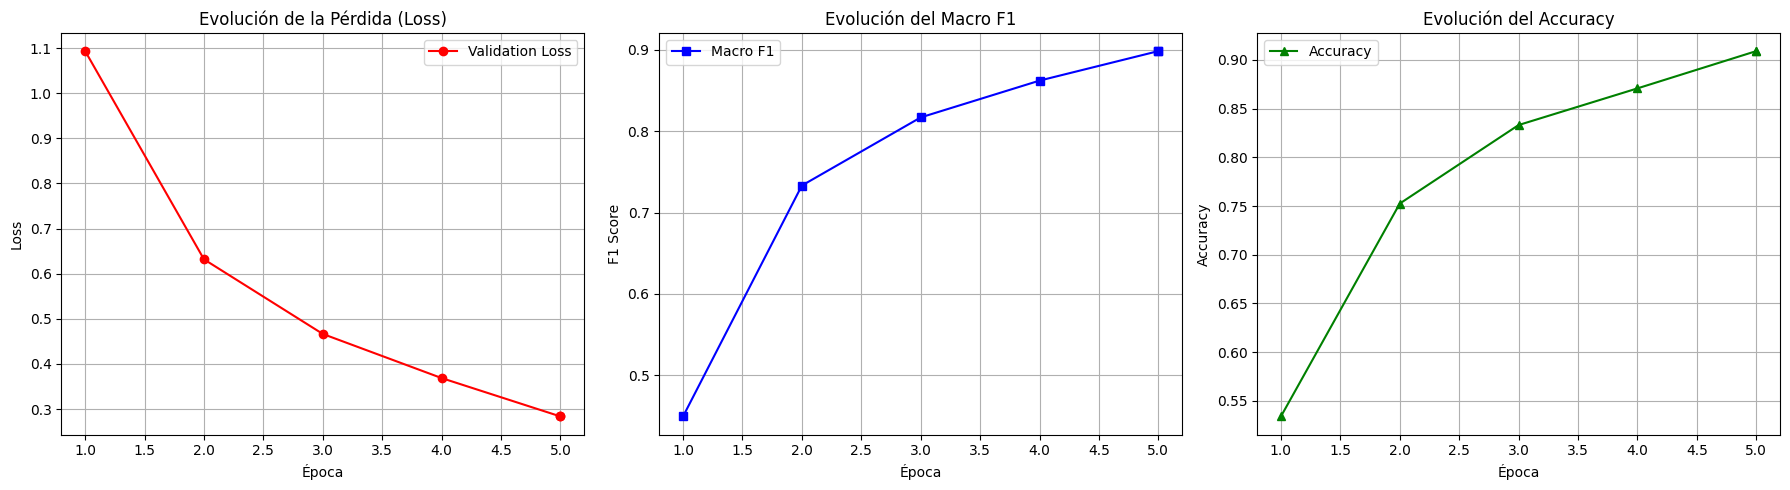

In [22]:
import matplotlib.pyplot as plt

# Extraemos los logs del trainer
history = trainer.state.log_history

# Filtramos los logs que contienen métricas de evaluación
eval_logs = [log for log in history if 'eval_loss' in log]
epochs = [log['epoch'] for log in eval_logs]
losses = [log['eval_loss'] for log in eval_logs]
f1_scores = [log['eval_f1: '] for log in eval_logs]
accuracy_scores = [log['eval_accuracy: '] for log in eval_logs]

# Crear la figura con tres subplots
plt.figure(figsize=(18, 5))

# Subplot 1: Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, losses, label='Validation Loss', marker='o', color='red')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Subplot 2: F1-Score
plt.subplot(1, 3, 2)
plt.plot(epochs, f1_scores, label='Macro F1', marker='s', color='blue')
plt.title('Evolución del Macro F1')
plt.xlabel('Época')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()

# Subplot 3: Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs, accuracy_scores, label='Accuracy', marker='^', color='green')
plt.title('Evolución del Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Inferencia sobre texto rellenar tags

In [23]:
df_test = pd.read_csv("tcga_simple_test_empty.csv")
df_test.head()

,patient_id,text,t
0,TCGA-IN-A6RO,"FINAL DIAGNOSIS: PART 1: ESOPHAGUS, ESOPHAGECT...",NaN
1,TCGA-SX-A7SL,DIAGNOSIS: A. Left kidney: Papillary renal cel...,NaN
2,TCGA-2Y-A9H2,"Final Diagnosis. A. LIVER, LEFT LATERAL SEGMEN...",NaN
3,TCGA-D5-6923,page 1 / 1. copy No. 2. Examination: Histopath...,NaN
4,TCGA-CZ-5463,Report Status: Amend/Addenda. Type: Surgical P...,NaN


In [24]:
from datasets import Dataset

# 1. Convertimos el DataFrame de test a un objeto Dataset de Hugging Face
dataset_test_hf = Dataset.from_pandas(df_test)

# 2. Tokenizamos los textos del test usando la función y el tokenizer ya definidos
# Recordamos que MAX_LENGTH es 512
encoded_test_hf = dataset_test_hf.map(tokenize, batched=True)

# 3. Realizamos la predicción con el trainer
print("Iniciando inferencia sobre el dataset de test...")
test_preds_output = trainer.predict(encoded_test_hf)

# 4. Obtenemos el índice de la clase con mayor probabilidad para cada fila
preds_indices = test_preds_output.predictions.argmax(-1)

# 5. Mapeamos los IDs numéricos de vuelta a las etiquetas originales (T1, T2, T3, T4)
# Usamos el diccionario inverso de label2id
id2label = {v: k for k, v in label2id.items()}
df_test['t'] = [id2label[idx] for idx in preds_indices]

# 6. Mostramos los resultados finales
print("Inferencia completada.")
display(df_test[['patient_id', 'text', 't']].head(10))

Map:   0%|          | 0/1032 [00:00<?, ? examples/s]

Iniciando inferencia sobre el dataset de test...


Inferencia completada.


,patient_id,text,t
0,TCGA-IN-A6RO,"FINAL DIAGNOSIS: PART 1: ESOPHAGUS, ESOPHAGECT...",T1
1,TCGA-SX-A7SL,DIAGNOSIS: A. Left kidney: Papillary renal cel...,T1
2,TCGA-2Y-A9H2,"Final Diagnosis. A. LIVER, LEFT LATERAL SEGMEN...",T1
3,TCGA-D5-6923,page 1 / 1. copy No. 2. Examination: Histopath...,T2
4,TCGA-CZ-5463,Report Status: Amend/Addenda. Type: Surgical P...,T3
5,TCGA-78-8648,HISTORY. Histopathology of right upper lobe an...,T2
6,TCGA-BB-7864,INTERPRE'TATION AND DIAGNOSIS: 1) LARYNX (PART...,T2
7,TCGA-RC-A7SK,"A and C. Liver, left. lobectony : HEPATOCELLUL...",T2
8,TCGA-A7-A26J,Date Coll: SPECIMEN. A. Left axillary sentinel...,T2
9,TCGA-43-6647,SPECIMEN. A. Level 1. B. Level 7. C. Level 4. ...,T2


In [25]:
# Guardar el DataFrame con las predicciones en un archivo CSV
output_filename = 'tcga_predictions_test.csv'
df_test[['patient_id', 'text', 't']].to_csv(output_filename, index=False)

print(f"Resultados guardados exitosamente en: {output_filename}")

Resultados guardados exitosamente en: tcga_predictions_test.csv
